# 06_08 - per-cell isoform entropy with an UNCONDITIONAL denominator, isoform level

In [ ]:
# relocation-proof bootstrap
import os
import sys

_d = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_d, '.notebooks_root')):
    _p = os.path.dirname(_d)
    if _p == _d:
        raise RuntimeError('could not locate .notebooks_root above this notebook')
    _d = _p
os.chdir(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)
print('working dir:', os.getcwd())

import gc
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.sparse import issparse, csr_matrix
import matplotlib
import matplotlib.pyplot as plt

import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath
import senescence_robustness as sr
importlib.reload(sr)

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.width', 240)

working dir: /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks


In [3]:
# preferred plot formatting
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0
plt.rcParams.update({
    'font.size': 6, 'axes.titlesize': 6, 'axes.labelsize': 6,
    'xtick.labelsize': 6, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'legend.title_fontsize': 6,
    'legend.labelspacing': 0.1, 'legend.borderpad': 0.3, 'legend.handletextpad': 0.2,
    'figure.titlesize': 6,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'figure.titleweight': 'bold',
    'xtick.major.size': TICK_LEN, 'ytick.major.size': TICK_LEN,
    'xtick.major.pad': TICK_LABEL_PAD, 'ytick.major.pad': TICK_LABEL_PAD,
    'axes.labelpad': AXIS_LABEL_PAD,
})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

UP_COLOR = '#c44e52'
DOWN_COLOR = '#4c72b0'
# identical to 06_43c's, so the standalone Fig. 4D-format panel below colours donors the same
DONOR_PALETTE = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860']

H5AD_DIR = '../pacbio/h5ads'
CSV_DIR = '../csvs'
OUT = CSV_DIR + '/06_36_robustness'
os.makedirs(OUT, exist_ok=True)
OBJ = (H5AD_DIR + '/all_samples_pacbio_recollapsed_raw_counts_ensemblids_annotatedonly'
       '_bc_anndata_preprocessed_with_isofrac_xgen_cdkn2a.h5ad')
STATUS_COL = 'xgen_cdkn2a_raw_status'

# --- parameters copied from 06_43c so the arms stay comparable --------------------
# ISOFORM-level library size, not obs['total_counts'].
# 06_10 and 06_11 match on `adata.X.sum(axis=1)`; this notebook used
# obs['total_counts'], which 01_08 stores from the GENE-level matrix. The two are
# different quantities, so the depth quantiles differed and the three notebooks
# produced non-identical matched arms (6,038 cells here vs 6,041 there) despite the
# same object, key, bins and seed. Section 1 backfills this column into the cache.
DEPTH = 'iso_total_counts'
UNIT_COL = 'tube_id'
N_BINS = 1                 # no depth stratification in the PRIMARY estimate, as 06_43c
MIN_PER_STRATUM = 5
MIN_PER_STRATUM_CT = 3     # (tube x depth) blocks are much thinner per cell class

# --- what this notebook adds ------------------------------------------------------
# ESTIMANDS drives every loop below; PRIMARY is what the readout and the per-class
# panel select on. Adding 'conditional' back restores a second arm everywhere.
ESTIMANDS = ['unconditional']
PRIMARY = 'unconditional'
MATCH_BINS = 20            # depth bins for 1:1 matching in the robustness ladder
GENE_FLOOR = 5             # molecules of a gene in a cell, for the floor arm
LADDER_THIN_PCT = 10       # thin to this percentile of the matched set's depth
RANDOM_SEED = 0

# Cache. The filename says `_both` and the file carries the conditional columns:
# section 1 computes them in the same pass and the decomposition needs entropy_cond
# as M_i, so rewriting the schema would force a recompute for nothing.
ENTROPY_CACHE = CSV_DIR + '/06_03_diversity_cache/06_08_per_cell_entropy_isoforms_both.csv'
final = {}
print(f'estimands {ESTIMANDS}, primary = {PRIMARY}   depth bins {N_BINS}   unit {UNIT_COL}')

estimands ['unconditional'], primary = unconditional   depth bins 1   unit tube_id


## 1. Per-cell entropy under both denominators, one pass


In [4]:
import scanpy as sc

if not os.path.exists(ENTROPY_CACHE):
    print('cache absent -- computing from the ISOFORM object', flush=True)
    _a = sc.read_h5ad(OBJ)
    _gc = ('pigeon_associated_gene' if 'pigeon_associated_gene' in _a.var.columns
           else 'gene_name')
    _a = _a[:, _a.var[_gc].notna().values].copy()
    _i2g, _goi, _genes, _gci = sr.build_iso_to_gene(_a.var[_gc].astype(str).values)
    _fr = _a.layers['isoform_fraction']
    _fr = _fr.tocsr() if issparse(_fr) else csr_matrix(_fr)

    n = _fr.shape[0]
    H_un = np.full(n, np.nan)
    H_co = np.full(n, np.nan)
    k_expr = np.zeros(n, dtype=int)
    k_meas = np.zeros(n, dtype=int)
    BATCH = 2000
    for s0 in range(0, n, BATCH):
        e0 = min(s0 + BATCH, n)
        b = _fr[s0:e0]
        term = b.copy()
        term.data = -term.data * np.log2(np.maximum(term.data, 1e-300))
        ge = np.asarray((term @ _i2g).todense(), dtype=np.float64)
        ne = np.asarray(((b > 0).astype(np.float32) @ _i2g).todense())
        expr = ne >= 1
        meas = ne >= 2
        # THE IDENTITY THIS NOTEBOOK RESTS ON: gene_entropy is already 0 wherever only one
        # isoform was seen, so masking on `expr` and on `meas` gives the same numerator.
        tot_e = np.where(expr, ge, 0.0).sum(axis=1)
        tot_m = np.where(meas, ge, 0.0).sum(axis=1)
        assert np.abs(tot_e - tot_m).max() < 1e-9, 'numerator differs between conventions'
        ke = expr.sum(axis=1)
        km = meas.sum(axis=1)
        H_un[s0:e0] = np.divide(tot_e, ke, out=np.full(e0 - s0, np.nan), where=ke > 0)
        H_co[s0:e0] = np.divide(tot_e, km, out=np.full(e0 - s0, np.nan), where=km > 0)
        k_expr[s0:e0] = ke
        k_meas[s0:e0] = km
        del b, term, ge, ne, expr, meas
        gc.collect()
        print(f'  {e0:,}/{n:,}', flush=True)

    # entropy_cond is M_i in the decomposition below, a factor of the unconditional
    # estimand rather than a rival to it.
    _iso_tot = np.asarray(_a.X.sum(axis=1)).ravel()   # isoform-level library size
    pd.DataFrame({'entropy_uncond': H_un, 'entropy_cond': H_co,
                  'k_expr': k_expr, 'k_meas': k_meas,
                  'iso_total_counts': _iso_tot},
                 index=_a.obs_names).to_csv(ENTROPY_CACHE)
    print(f'wrote {ENTROPY_CACHE}')
    del _a, _fr
    gc.collect()

ent = pd.read_csv(ENTROPY_CACHE, index_col=0)

# Backfill for caches that hold only the entropy columns. Costs a single pass over the
# object; after it the cache carries the column and this branch never runs again.
if 'iso_total_counts' not in ent.columns:
    print('cache lacks iso_total_counts -- backfilling from the object', flush=True)
    _b = sc.read_h5ad(OBJ)
    ent['iso_total_counts'] = (pd.Series(np.asarray(_b.X.sum(axis=1)).ravel(),
                                         index=_b.obs_names)
                               .reindex(ent.index).values)
    assert np.isfinite(ent['iso_total_counts']).all(), \
        'iso_total_counts has NaN -- cache index does not match the object'
    ent.to_csv(ENTROPY_CACHE)
    del _b
    gc.collect()
    print(f'  wrote {ENTROPY_CACHE} with iso_total_counts')

obs = sr.read_h5ad_obs(OBJ)
for c in ent.columns:
    obs[c] = ent[c].reindex(obs.index).values

status = obs[STATUS_COL].astype(str)
keep = ~status.isin(['other_CDKN2A+', 'p14ARF+'])
sub = obs[keep.values].copy()
sub['is_senescent'] = status[keep.values].isin(['p16+', 'Both']).values
sub[UNIT_COL] = sub[UNIT_COL].astype(str)
n_sen = int(sub.is_senescent.sum())
n_non = int((~sub.is_senescent).sum())
print(f'\ncells {len(sub):,}  senescent {n_sen:,}  non-senescent {n_non:,}  '
      f'tubes {sub[UNIT_COL].nunique()}  donors {sub.donor.nunique()}')
d_sen = sub.loc[sub.is_senescent, DEPTH].values
d_non = sub.loc[~sub.is_senescent, DEPTH].values
if 'total_counts' in sub.columns:
    _r_iso = np.median(d_sen) / max(np.median(d_non), 1)
    _g_sen = sub.loc[sub.is_senescent, 'total_counts'].values
    _g_non = sub.loc[~sub.is_senescent, 'total_counts'].values
    print(f"depth definitions: isoform-level ratio {_r_iso:.2f}x vs gene-level "
          f"total_counts ratio {np.median(_g_sen) / max(np.median(_g_non), 1):.2f}x "
          f"-- matching uses the ISOFORM-level column, as 06_10/06_11 do")
print(f'depth ({DEPTH}) median senescent {np.median(d_sen):,.0f}  '
      f'non-senescent {np.median(d_non):,.0f}  '
      f"ratio {np.median(d_sen) / np.median(d_non):.2f}x   "
      f"Cliff's delta {sr.cliffs_delta(d_sen, d_non):+.3f}")
final['depth_ratio'] = float(np.median(d_sen) / np.median(d_non))



cells 154,182  senescent 3,134  non-senescent 151,048  tubes 50  donors 4
depth definitions: isoform-level ratio 1.99x vs gene-level total_counts ratio 2.24x -- matching uses the ISOFORM-level column, as 06_10/06_11 do
depth (iso_total_counts) median senescent 3,680  non-senescent 1,847  ratio 1.99x   Cliff's delta +0.449


## 2. Decomposition: detection x evenness, per cell


In [5]:
sub['D_cell'] = np.where(sub.k_expr > 0, sub.k_meas / np.maximum(sub.k_expr, 1), np.nan)
sub['M_cell'] = sub.entropy_cond
_ok = np.isfinite(sub.entropy_uncond) & np.isfinite(sub.D_cell) & np.isfinite(sub.M_cell)
assert np.nanmax(np.abs((sub.D_cell * sub.M_cell - sub.entropy_uncond)[_ok])) < 1e-9, \
    'per-cell decomposition does not close'
print(f'decomposition closes on {int(_ok.sum()):,} cells')

g = sub.groupby('is_senescent')
tab = pd.DataFrame({
    'k_expr (genes expressed)': g.k_expr.median(),
    'k_meas (multi-isoform)': g.k_meas.median(),
    'D = k_meas / k_expr': g.D_cell.median(),
    'M = conditional entropy': g.M_cell.median(),
    'H unconditional': g.entropy_uncond.median(),
}).T
tab.columns = ['non-senescent', 'senescent']
print()
print(tab.round(4).to_string())
print()
print(f"D ratio  senescent / non-senescent : "
      f"{tab.loc['D = k_meas / k_expr', 'senescent'] / tab.loc['D = k_meas / k_expr', 'non-senescent']:.2f}x")
print(f"k_expr ratio                       : "
      f"{tab.loc['k_expr (genes expressed)', 'senescent'] / tab.loc['k_expr (genes expressed)', 'non-senescent']:.2f}x")
print()
print('k_expr is the number of genes the cell expresses, so it scales with depth directly.')
print('The two arms therefore average over gene sets of different SIZE and composition --')
print('an exposure neither denominator removes, and one that cell-depth stratification does')
print('not remove either, since it balances library size rather than which genes qualify.')
final['median_D_sen'] = float(tab.loc['D = k_meas / k_expr', 'senescent'])
final['median_D_non'] = float(tab.loc['D = k_meas / k_expr', 'non-senescent'])

decomposition closes on 154,182 cells

                          non-senescent  senescent
k_expr (genes expressed)       831.0000  1461.0000
k_meas (multi-isoform)          90.0000   238.5000
D = k_meas / k_expr              0.1114     0.1656
M = conditional entropy          0.9946     1.0160
H unconditional                  0.1102     0.1674

D ratio  senescent / non-senescent : 1.49x
k_expr ratio                       : 1.76x

k_expr is the number of genes the cell expresses, so it scales with depth directly.
The two arms therefore average over gene sets of different SIZE and composition --
an exposure neither denominator removes, and one that cell-depth stratification does
not remove either, since it balances library size rather than which genes qualify.


## 3. Primary estimate: tube-level, both denominators


In [6]:
dbin = sr.depth_bin(sub[DEPTH].values, n_bins=N_BINS)
tube_to_donor = sub.drop_duplicates(UNIT_COL).set_index(UNIT_COL)['donor']

primary, tube_tables = {}, {}
for est in ESTIMANDS:
    col = 'entropy_uncond'   # single estimand since 2026-08-22
    m = np.isfinite(sub[col].values)
    te = sr.stratified_unit_effects(sub[col].values[m], sub['is_senescent'].values[m],
                                    sub[UNIT_COL].values[m], dbin[m],
                                    min_per_stratum=MIN_PER_STRATUM, unit_name=UNIT_COL)
    te['donor'] = te[UNIT_COL].map(tube_to_donor)
    fl = sr.dersimonian_laird(te['effect'].values, te['se'].values)
    sf = sr.sign_flip_test(te['effect'].values)
    n_pos = int((te['effect'] > 0).sum())
    primary[est] = {'effect': fl['effect'], 'ci_low': fl['ci_low'], 'ci_high': fl['ci_high'],
                    'p': fl['p'], 'I2': fl.get('I2', np.nan), 'k_tubes': int(fl['k']),
                    'n_tubes_positive': n_pos, 'p_signflip': sf.get('p', np.nan),
                    'n_cells_used': int(m.sum())}
    tube_tables[est] = te
    te.to_csv(f'{OUT}/06_08_per_tube_effects_{est}.csv', index=False)
    print(f'{est:>14}: effect {fl["effect"]:+.5f}  '
          f'CI [{fl["ci_low"]:+.5f}, {fl["ci_high"]:+.5f}]  p {fl["p"]:.3g}  '
          f'{n_pos}/{int(fl["k"])} tubes positive  I2 {fl.get("I2", float("nan")):.0f}%')
    print(f'{"":>14}  ({len(te)} tubes in the table, {int(fl["k"])} estimable -- the rest '
          f'hold < {MIN_PER_STRATUM} cells in an arm and carry an empty effect)')

pd.DataFrame(primary).T.to_csv(f'{OUT}/06_08_primary_by_estimand.csv')
final['primary_effect'] = float(primary[PRIMARY]['effect'])
final['primary_ci_low'] = float(primary[PRIMARY]['ci_low'])
final['primary_ci_high'] = float(primary[PRIMARY]['ci_high'])
final['primary_n_tubes_positive'] = primary[PRIMARY]['n_tubes_positive']
final['primary_k_tubes'] = primary[PRIMARY]['k_tubes']


 unconditional: effect +0.05396  CI [+0.04227, +0.06565]  p 4.51e-11  35/36 tubes positive  I2 94%
                (50 tubes in the table, 36 estimable -- the rest hold < 5 cells in an arm and carry an empty effect)


## 4. Robustness ladder


In [7]:
rng = np.random.default_rng(RANDOM_SEED)

# ---------------------------------------------------------------- DEPTH MATCHING
# MATCH_WITHIN nests the 1:1 match inside a grouping: the depth quantiles are
# recomputed within each group instead of over the pooled cohort. Set it to None to
# restore the pooled design this notebook used previously.
#   None      -> pooled over all ~154k cells at once
#   'tube_id' -> matched WITHIN SAMPLE: a tube's senescent cells are only ever
#                compared against reference cells drawn from that same tube
#   a LIST    -> nested on the composite key, e.g. sample AND cell type
# ⚠ NESTING DEPTH. (tube_id x broad_cell_class) is a MUCH finer grouping than tube_id
# alone: ~50 tubes x ~34 classes is up to ~1,700 groups, and MATCH_BINS quantiles are
# recomputed inside each. A block contributes only if it holds BOTH arms, so senescent
# cells in thin (tube, class) combinations are dropped. Check the retention print below
# before quoting anything: if it falls far, lower MATCH_BINS (3-5 is reasonable at this
# nesting) rather than accepting a biased survivor set.
MATCH_WITHIN = ['tube_id']

if MATCH_WITHIN is None:
    _within, _scheme = None, 'pooled (all cells at once)'
else:
    _cols = [MATCH_WITHIN] if isinstance(MATCH_WITHIN, str) else list(MATCH_WITHIN)
    _s = sub[_cols[0]].astype(str)
    for _c in _cols[1:]:
        _s = _s.str.cat(sub[_c].astype(str), sep='||')
    _within, _scheme = _s.values, ' x '.join(_cols)

_n_sen_all = int(sub['is_senescent'].sum())
mi, mj = sr.depth_matched_indices(sub[DEPTH].values, sub['is_senescent'].values,
                                  n_bins=MATCH_BINS, seed=RANDOM_SEED, ratio=1,
                                  within=_within)
matched = np.sort(np.concatenate([mi, mj]))
sm = sub.iloc[matched]
_n_sen_m = int(sm.is_senescent.sum())

print(f'depth matching: {_scheme.upper()}'
      + (f'  ({len(pd.unique(_within)):,} groups)' if _within is not None else ''))
print(f'depth-matched subsample: {len(matched):,} cells '
      f'({_n_sen_m:,} senescent, {int((~sm.is_senescent).sum()):,} reference)')
print(f'  senescent retained: {_n_sen_m:,}/{_n_sen_all:,} ({100 * _n_sen_m / _n_sen_all:.1f}%)')
if _n_sen_m < _n_sen_all:
    print('  NOTE: inside a thin group the reference arm can be the scarcer one, in which')
    print('        case senescent cells are subsampled to match. The 1:1 balance holds, but')
    print('        "every senescent cell retained" no longer does.')
print(f'  median depth  senescent {np.median(sm.loc[sm.is_senescent, DEPTH]):,.0f}  '
      f'reference {np.median(sm.loc[~sm.is_senescent, DEPTH]):,.0f}  '
      f"Cliff's delta {sr.cliffs_delta(sm.loc[sm.is_senescent, DEPTH].values, sm.loc[~sm.is_senescent, DEPTH].values):+.3f}")

# A pooled match balances depth only marginally, and this notebook's estimator blocks
# on tube, so the number that actually matters is the residual gap INSIDE each tube.
_res, _ok_tubes = [], 0
_sen_m, _tub_m, _dep_m = sm.is_senescent.values, sm[UNIT_COL].values, sm[DEPTH].values
for _t in pd.unique(_tub_m):
    _m = _tub_m == _t
    _a2, _b2 = _dep_m[_m & _sen_m], _dep_m[_m & ~_sen_m]
    if _a2.size >= 3 and _b2.size >= 3:
        _res.append(abs(sr.cliffs_delta(_a2, _b2)))
    if _a2.size >= MIN_PER_STRATUM and _b2.size >= MIN_PER_STRATUM:
        _ok_tubes += 1
if _res:
    print(f"  residual |Cliff's delta| WITHIN tube: median {np.median(_res):.3f}  "
          f"max {np.max(_res):.3f}  over {len(_res)} tubes with both arms")
print(f'  tubes clearing {MIN_PER_STRATUM} cells per arm: {_ok_tubes} of '
      f'{sub[UNIT_COL].nunique()}   (pooled matching gave 35 of 50)')

# The ladder's extra arms need counts, so the object is reopened for the matched cells only --
# 6k cells rather than 154k, which keeps the dense gene-level array small.
_a = sc.read_h5ad(OBJ)
_gc = 'pigeon_associated_gene' if 'pigeon_associated_gene' in _a.var.columns else 'gene_name'
_a = _a[:, _a.var[_gc].notna().values].copy()
i2g, goi, gnames, gci = sr.build_iso_to_gene(_a.var[_gc].astype(str).values)
pos = pd.Index(_a.obs_names).get_indexer(sm.index)
assert (pos >= 0).all(), 'matched cells missing from the object'
Xm = (_a.X.tocsr() if issparse(_a.X) else csr_matrix(_a.X))[pos]
Fm = (_a.layers['isoform_fraction'].tocsr() if issparse(_a.layers['isoform_fraction'])
      else csr_matrix(_a.layers['isoform_fraction']))[pos]
gene_tot_m = np.asarray((Xm @ i2g).todense(), dtype=np.float32)
del _a
gc.collect()
print(f'matched-subset matrices: X {Xm.shape}, gene_tot {gene_tot_m.shape} '
      f'({gene_tot_m.nbytes / 1e9:.2f} GB)')


def unit_effect(values, mask_df):
    """Tube-level DL meta-analysis on an arbitrary per-cell value over a subset.

    Returns (summary_dict, per_tube_table). The table is returned as well as the summary
    because the paired-by-sample figure draws one line per tube from mean_ref_adj and
    mean_group_adj, and the depth-matched panel needs the matched subset's own table
    rather than the full-cohort one.
    """
    _empty = pd.DataFrame()
    ok = np.isfinite(values)
    if ok.sum() < 20:
        return {'effect': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'k': 0}, _empty
    db = sr.depth_bin(mask_df[DEPTH].values[ok], n_bins=N_BINS)
    te = sr.stratified_unit_effects(values[ok], mask_df['is_senescent'].values[ok],
                                    mask_df[UNIT_COL].values[ok], db,
                                    min_per_stratum=MIN_PER_STRATUM, unit_name=UNIT_COL)
    if not len(te):
        return {'effect': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'k': 0}, _empty
    return sr.dersimonian_laird(te['effect'].values, te['se'].values), te


THIN_T = int(np.percentile(sm[DEPTH].values, LADDER_THIN_PCT))
print(f'ladder thinning target: {THIN_T:,} counts '
      f'({LADDER_THIN_PCT}th percentile of matched depth)')
Xt = sr.thin_to_depth(Xm, THIN_T, rng)
Ft = sr.counts_to_fractions(Xt, i2g, goi)

ladder = []
tube_tables_matched = {}
for est in ESTIMANDS:
    mi_iso = 1
    col = 'entropy_uncond'   # single estimand since 2026-08-22

    r, _ = unit_effect(sub[col].values, sub)
    ladder.append({'estimand': est, 'design': 'tube-level, NOT depth-controlled (primary)',
                   **{k: r.get(k) for k in ('effect', 'ci_low', 'ci_high')},
                   'note': f'{len(sub):,} cells'})

    r, te_m = unit_effect(sm[col].values, sm)
    tube_tables_matched[est] = te_m
    ladder.append({'estimand': est, 'design': 'depth-MATCHED cells',
                   **{k: r.get(k) for k in ('effect', 'ci_low', 'ci_high')},
                   'note': f'{int((~sm.is_senescent).sum()):,} reference cells'})

    cs, _ = sr.chao_shen_entropy(Xm, gci, min_isoforms=mi_iso)
    r, _ = unit_effect(np.asarray(cs, dtype=float), sm)
    ladder.append({'estimand': est, 'design': 'depth-matched + Chao-Shen',
                   **{k: r.get(k) for k in ('effect', 'ci_low', 'ci_high')},
                   'note': 'bias correction, no conditioning -- discards no group difference'})

    fl_, _ = sr.per_cell_entropy_floor(Fm, gene_tot_m, i2g, GENE_FLOOR,
                                       min_isoforms_per_gene=mi_iso)
    r, _ = unit_effect(np.asarray(fl_, dtype=float), sm)
    ladder.append({'estimand': est, 'design': f'depth-matched + gene floor >= {GENE_FLOOR}',
                   **{k: r.get(k) for k in ('effect', 'ci_low', 'ci_high')},
                   'note': 'equalises sampling effort PER (cell, gene)'})

    tterm = Ft.copy()
    tterm.data = -tterm.data * np.log2(np.maximum(tterm.data, 1e-300))
    ge_t = np.asarray((tterm @ i2g).todense(), dtype=np.float64)
    ne_t = np.asarray(((Ft > 0).astype(np.float32) @ i2g).todense())
    kk = (ne_t >= mi_iso).sum(axis=1)
    ss = np.where(ne_t >= 1, ge_t, 0.0).sum(axis=1)
    ht = np.divide(ss, kk, out=np.full(len(kk), np.nan), where=kk > 0)
    r, _ = unit_effect(ht, sm)
    ladder.append({'estimand': est, 'design': f'depth-matched + thinned to {THIN_T:,}',
                   **{k: r.get(k) for k in ('effect', 'ci_low', 'ci_high')},
                   'note': 'equalises by construction; adds sampling noise, so CIs widen'})
    del tterm, ge_t, ne_t
    gc.collect()

lad = pd.DataFrame(ladder)
lad['excludes_zero'] = (lad.ci_low > 0) | (lad.ci_high < 0)
lad.to_csv(f'{OUT}/06_08_robustness_ladder.csv', index=False)
for est in ESTIMANDS:
    print()
    print(f'=== {est.upper()} ===')
    print(lad[lad.estimand == est][['design', 'effect', 'ci_low', 'ci_high',
                                    'excludes_zero', 'note']].round(5).to_string(index=False))
print(f'\nwrote 06_08_robustness_ladder.csv')
print()
print('A CI that includes zero after thinning is NOT by itself evidence against the effect:')
print('thinning adds sampling noise, so compare its CI against the depth-matched point')
print('estimate rather than against zero alone.')


depth matching: TUBE_ID  (50 groups)
depth-matched subsample: 6,097 cells (3,134 senescent, 2,963 reference)
  senescent retained: 3,134/3,134 (100.0%)
  median depth  senescent 3,680  reference 3,460  Cliff's delta +0.046
  residual |Cliff's delta| WITHIN tube: median 0.040  max 0.778  over 40 tubes with both arms
  tubes clearing 5 cells per arm: 36 of 50   (pooled matching gave 35 of 50)
matched-subset matrices: X (6097, 130362), gene_tot (6097, 18987) (0.46 GB)
ladder thinning target: 1,230 counts (10th percentile of matched depth)

=== UNCONDITIONAL ===
                                    design  effect  ci_low  ci_high  excludes_zero                                                             note
tube-level, NOT depth-controlled (primary) 0.05396 0.04227  0.06565           True                                                    154,182 cells
                       depth-MATCHED cells 0.01422 0.00805  0.02039           True                                            2,963 referen

## 5. Per broad cell class


In [8]:
ct_rows = []
for est in ESTIMANDS:
    col = 'entropy_uncond'   # single estimand since 2026-08-22
    m = np.isfinite(sub[col].values)
    ct = sr.stratified_unit_effects(sub[col].values[m], sub['is_senescent'].values[m],
                                    sub['broad_cell_class'].astype(str).values[m], dbin[m],
                                    min_per_stratum=MIN_PER_STRATUM_CT,
                                    unit_name='broad_cell_class')
    n_hi = int((ct['effect'] > 0).sum())
    ct['estimand'] = est
    ct_rows.append(ct)
    print(f'{est:>14}: {n_hi} of {len(ct)} broad classes higher in senescence   '
          f'binomial p {sr.binom_direction_p(n_hi, len(ct)):.4g}')
    final[f'ct_n_testable_{est}'] = len(ct)
    final[f'ct_n_higher_{est}'] = n_hi
ctall = pd.concat(ct_rows, ignore_index=True)
ctall.to_csv(f'{OUT}/06_08_per_celltype.csv', index=False)
print(f'\nwrote 06_08_per_celltype.csv')

 unconditional: 22 of 33 broad classes higher in senescence   binomial p 0.08014

wrote 06_08_per_celltype.csv


## 5b. Per broad cell class, DEPTH-MATCHED (replacement Supp. Fig. 11F)


 unconditional: 19 of 22 estimable broad classes higher in senescence (depth-MATCHED)   binomial p 0.0008554

wrote 06_08_per_celltype_matched.csv


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


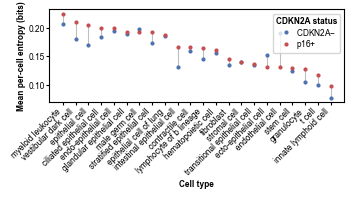


Per cell class, both arms, unconditional denominator on depth-MATCHED cells.
19 of 22 estimable classes higher in senescence.

NOTE the y axis does not start at zero -- entropy is ~1 bit in every class and the
shift is a few percent, so a zero-based axis would render every pair as one point.
State that in the legend.


In [9]:
# Colour convention carried over from the panel this replaces.
NON_COLOR = '#4c72b0'
SEN_COLOR = '#c44e52'

# One stratum: the matched arms already share a depth distribution (see the note above).
_one = np.zeros(len(sm), dtype=int)

ct_m_rows = []
for est in ESTIMANDS:
    col = 'entropy_uncond'   # single estimand since 2026-08-22
    m_ = np.isfinite(sm[col].values)
    ct_m = sr.stratified_unit_effects(sm[col].values[m_], sm['is_senescent'].values[m_],
                                      sm['broad_cell_class'].astype(str).values[m_], _one[m_],
                                      min_per_stratum=MIN_PER_STRATUM_CT,
                                      unit_name='broad_cell_class')
    ct_m['estimand'] = est
    ct_m_rows.append(ct_m)
    _ok = ct_m[ct_m['effect'].notna()]
    n_hi = int((_ok['effect'] > 0).sum())
    print(f'{est:>14}: {n_hi} of {len(_ok)} estimable broad classes higher in senescence '
          f'(depth-MATCHED)   binomial p {sr.binom_direction_p(n_hi, len(_ok)):.4g}')
    final[f'ct_matched_n_testable_{est}'] = int(len(_ok))
    final[f'ct_matched_n_higher_{est}'] = n_hi

ctall_m = pd.concat(ct_m_rows, ignore_index=True)
ctall_m.to_csv(f'{OUT}/06_08_per_celltype_matched.csv', index=False)
print(f'\nwrote 06_08_per_celltype_matched.csv')

# --- the panel, PRIMARY estimand only -----------------------------------------------------
ct_ok = ctall_m[(ctall_m.estimand == PRIMARY) & ctall_m['effect'].notna()].copy()
if not len(ct_ok):
    print(f'\nNothing to plot: no broad class is estimable under {PRIMARY} in the matched arm.')
    print('Matching discards most of the reference arm, so a class can clear '
          f'MIN_PER_STRATUM_CT={MIN_PER_STRATUM_CT} in section 5 and fail here. Lower it, or')
    print('report the stratified panel instead and say so in the legend.')
else:
    # mean_ref_adj and mean_group_adj come out of stratified_unit_effects using the SAME
    # weights as the effect, so the gap between the dots IS the effect -- assert it.
    _gap = (ct_ok['mean_group_adj'] - ct_ok['mean_ref_adj']).values
    assert np.allclose(_gap, ct_ok['effect'].values, atol=1e-12), \
        'arm means do not reproduce the plotted effect'

    ct_p = ct_ok.sort_values('mean_group_adj', ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(3.8, 1.2))
    x = np.arange(len(ct_p))
    for i, r in ct_p.iterrows():
        ax.plot([i, i], [r['mean_ref_adj'], r['mean_group_adj']], '-',
                lw=0.8, color='0.75', zorder=1, solid_capstyle='round')
    ax.plot(x, ct_p['mean_ref_adj'], 'o', ms=3.0, color=NON_COLOR, zorder=3,
            label='CDKN2A$-$', mew=0)
    ax.plot(x, ct_p['mean_group_adj'], 'o', ms=3.0, color=SEN_COLOR, zorder=3,
            label='p16$+$', mew=0)
    ax.set_xticks(x)
    ax.set_xticklabels([r['broad_cell_class'] for _, r in ct_p.iterrows()],
                       rotation=45, ha='right', va='top')
    ax.set_xlabel('Cell type')
    ax.set_ylabel('Mean per-cell entropy (bits)')
    leg = ax.legend(frameon=True, loc=1, title='CDKN2A status',
                    bbox_to_anchor=(1.0, 1.0), handletextpad=0.2)
    leg.get_title().set_weight('bold')
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
    fig.savefig(figpath('06_08_supp11f_percelltype_entropy_matched.pdf'),
                bbox_inches='tight', dpi=300)
    # plt.ylim((0.0, 0.30))
    plt.show()

    _n_hi = int((ct_p['effect'] > 0).sum())
    print(f'\nPer cell class, both arms, {PRIMARY} denominator on depth-MATCHED cells.')
    print(f'{_n_hi} of {len(ct_p)} estimable classes higher in senescence.')
    print()
    print('NOTE the y axis does not start at zero -- entropy is ~1 bit in every class and the')
    print('shift is a few percent, so a zero-based axis would render every pair as one point.')
    print('State that in the legend.')

## 6. Figures


row 1: all 154,182 cells
row 2: 6,097 depth-matched cells (3,134 senescent + 2,963 reference)
  all cells      unconditional  +0.05396 bits  35/36 samples up
  depth-matched  unconditional  +0.01422 bits  30/36 samples up


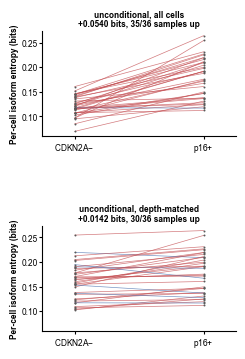

In [10]:
# Fig. 5D layout: one line per sample joining its two arm means, drawn for each estimand and,
# on the row below, the SAME thing on the 1:1 depth-matched subsample. That second row is the
# comparison the published panel does not show: it is the same figure with the depth difference
# between the arms removed by construction rather than adjusted for.
#
# y is shared DOWN each column, so the shift between the two rows is read directly instead of
# being rescaled away. Matching drops the shallow reference cells, which moves the CDKN2A- arm
# on its own -- that movement is the point, and hiding it behind independent axes would be
# misleading.
ROWS = [('all cells', tube_tables), ('depth-matched', tube_tables_matched)]
print(f'row 1: all {len(sub):,} cells')
print(f'row 2: {len(sm):,} depth-matched cells '
      f'({int(sm.is_senescent.sum()):,} senescent + {int((~sm.is_senescent).sum()):,} reference)')

fig, axes = plt.subplots(len(ROWS), len(ESTIMANDS),
                         figsize=(1.8 * len(ESTIMANDS) + 0.7, 1.8 * len(ROWS) + 0.3),
                         gridspec_kw={'wspace': 0.6, 'hspace': 0.85},
                         sharey='col', squeeze=False)
for ri, (rlab, tabs) in enumerate(ROWS):
    for ci, est in enumerate(ESTIMANDS):
        ax = axes[ri][ci]
        te = tabs.get(est)
        # stratified_unit_effects returns a row for EVERY unit, including ones it could not
        # estimate -- those come back with n_strata = 0 and an empty effect. On this object
        # that is 50 tubes of which 36 clear MIN_PER_STRATUM in both arms. Filtering here is
        # what makes the "n/k samples up" denominator the TESTED count, matching
        # dersimonian_laird's k and the draft's "30 of 36 samples"; len(te) would say 50.
        if te is not None and len(te):
            te = te[np.isfinite(te['effect'].values)]
        if te is None or not len(te):
            ax.set_axis_off()
            ax.set_title(f'{est}\n{rlab}: nothing estimable', pad=PANEL_TITLE_PAD)
            continue
        lo = te['mean_ref_adj'].values
        hi = te['mean_group_adj'].values
        for a, b in zip(lo, hi):
            ax.plot([0, 1], [a, b], color=(UP_COLOR if b > a else DOWN_COLOR),
                    lw=0.5, alpha=0.75, solid_capstyle='round')
        ax.scatter(np.zeros(len(lo)), lo, s=2, color='0.35', zorder=3, linewidths=0)
        ax.scatter(np.ones(len(hi)), hi, s=2, color='0.35', zorder=3, linewidths=0)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['CDKN2A$-$', 'p16$+$'])
        ax.set_xlim(-0.25, 1.25)
        if ci == 0:
            ax.set_ylabel('Per-cell isoform entropy (bits)')
        _dl = sr.dersimonian_laird(te['effect'].values, te['se'].values)
        _npos = int((te['effect'] > 0).sum())
        ax.set_title(f'{est}, {rlab}\n{_dl["effect"]:+.4f} bits, '
                     f'{_npos}/{len(te)} samples up', pad=PANEL_TITLE_PAD)
        for _sp in ('top', 'right'):
            ax.spines[_sp].set_visible(False)
        ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
        print(f'  {rlab:<14} {est:<14} {_dl["effect"]:+.5f} bits  '
              f'{_npos}/{len(te)} samples up')
fig.savefig(figpath('06_08_fig5d_paired_by_sample.pdf'), bbox_inches='tight', dpi=300)
plt.show()

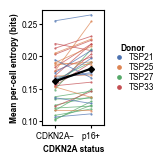

[ok] every slope equals its sample effect exactly
unconditional, depth-matched: +0.01422 bits  CI [+0.00805, +0.02039]  p 4.25e-05  30/36 samples up
wrote /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks/figures/figure4/06_08_fig4d_unconditional_depth_matched.pdf


In [11]:
# --- STANDALONE PANEL IN FIG. 4D FORMAT: unconditional, depth-matched only ---------------
# The layout 06_43c cell 16 uses for the published Fig. 4D panel
# (06_43c_fig5d_paired_by_sample.pdf), reproduced exactly: same figsize, donor colouring from
# DONOR_PALETTE, black median line with diamond markers, same axis limits, tick labels, axis
# labels and legend placement. Only the INPUT differs -- Fig. 4D is the conditional estimand
# with no depth control, this is the unconditional estimand on the 1:1 depth-matched
# subsample -- so the two can be swapped in a layout without any restyling.
te4d = tube_tables_matched.get('unconditional')
if te4d is None or not len(te4d):
    print('no depth-matched unconditional per-tube table -- run section 4 first')
else:
    # stratified_unit_effects returns a row for EVERY unit, including ones it could not
    # estimate (empty effect). 06_43c drops them with dropna(subset=['effect']); same here, so
    # the panel and its sample count describe the tested samples rather than all tubes.
    te4d = te4d.dropna(subset=['effect']).copy()
    te4d['donor'] = te4d[UNIT_COL].map(tube_to_donor)

    donors4d = sorted(te4d['donor'].dropna().unique())
    cmap4d = {d: DONOR_PALETTE[i % len(DONOR_PALETTE)] for i, d in enumerate(donors4d)}

    fig, ax = plt.subplots(figsize=(0.8, 1.5))
    for _, r in te4d.iterrows():
        ax.plot([0, 1], [r['mean_ref_adj'], r['mean_group_adj']],
                '-', lw=0.6, alpha=0.75, color=cmap4d.get(r['donor'], '0.5'), zorder=2,
                marker='o', ms=1.6, markeredgewidth=0)
    ax.plot([0, 1], [te4d['mean_ref_adj'].median(), te4d['mean_group_adj'].median()],
            '-', lw=1.6, color='k', zorder=3, marker='D', ms=3.0)
    ax.set_xlim(-0.35, 1.35)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['CDKN2A$-$', 'p16$+$'])
    ax.set_xlabel('CDKN2A status')
    ax.set_ylabel('Mean per-cell entropy (bits)')
    leg = ax.legend(handles=[plt.Line2D([], [], color=cmap4d[d], marker='o', ls='',
                                        ms=2.4, label=d) for d in donors4d],
                    frameon=False, title='Donor', loc=6, bbox_to_anchor=(1.0, 0.5),
                    ncol=1, handletextpad=0.1, labelspacing=0.10)
    leg.get_title().set_fontweight('bold')
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
    fig.savefig(figpath('06_08_fig4d_unconditional_depth_matched.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()

    # the guarantee 06_43c asserts on its own panel: every drawn slope IS that sample's
    # effect, because both endpoints come from the same weights the effect is computed from
    _gap = (te4d['mean_group_adj'] - te4d['mean_ref_adj']).values
    assert np.allclose(_gap, te4d['effect'].values, atol=1e-12), \
        'paired-plot slopes do not equal the per-sample effects'
    _dl = sr.dersimonian_laird(te4d['effect'].values, te4d['se'].values)
    print('[ok] every slope equals its sample effect exactly')
    print(f"unconditional, depth-matched: {_dl['effect']:+.5f} bits  "
          f"CI [{_dl['ci_low']:+.5f}, {_dl['ci_high']:+.5f}]  p {_dl['p']:.3g}  "
          f"{int((te4d['effect'] > 0).sum())}/{len(te4d)} samples up")
    print('wrote', figpath('06_08_fig4d_unconditional_depth_matched.pdf'))